In [2]:
import pandas as pd
import numpy as np

In [2]:
from contrailstereo.validation import metrics as M

M.decomposition("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv")

{'gate': 0.6,
 'n': 10932,
 'n_scenes': 183,
 'total': 0.5835515312974744,
 'within': 0.43004188296752865,
 'between': 0.3944570554234892}

In [3]:
M.map_tradeoff("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv")


,gate,n_profiles,n_scenes,coverage,rmse_raw,rmse_corr_insample,bias
0,0.5,11793,186,0.936770,0.679574,0.614391,-0.290422
1,0.6,10932,183,0.868377,0.656401,0.583552,-0.300549
2,0.7,9676,166,0.768608,0.636428,0.564468,-0.293966


In [4]:
M.bias_correct_cv("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv")

{'gate': 0.6,
 'n': 10932,
 'k': 5,
 'rmse_cv_corrected': 0.5853753423109512,
 'constant': -0.28907593429074047}

In [5]:
M.scene_summary("/Users/lewisclark/Documents/python_work/stereo/outputs/results_1315.csv")

{'n_scenes': 248,
 'n_ok': 172,
 'n_data_invalid': 60,
 'yield_of_valid': np.float64(0.9148936170212766),
 'bias': -0.38093037574234195,
 'rmse_raw': 0.5738891332430954,
 'rmse_loo_corr': 0.43174292102537276,
 'ci95': (0.3417616430071407, 0.5230474917785223),
 'verdicts': {'ok': 172,
  'coverage': 48,
  'no_data': 12,
  'low_edge': 8,
  'no_peak': 4,
  'offset': 3,
  'low_r': 1}}

[np.float64(0.3), np.float64(0.35), np.float64(0.39999999999999997), np.float64(0.44999999999999996), np.float64(0.49999999999999994), np.float64(0.5499999999999999), np.float64(0.5999999999999999), np.float64(0.6499999999999999), np.float64(0.7), np.float64(0.7499999999999999), np.float64(0.7999999999999998), np.float64(0.8499999999999999)] [0.6481418169639852, 0.646659569231401, 0.644547867900529, 0.6243456408678723, 0.6157569105439935, 0.5932588464680877, 0.5853753423109512, 0.5676801595983483, 0.5680860291269643, 0.5267557668311881, 0.4781983011725074, 0.44613159993812035] [0.9980935737548654, 0.9928509015807451, 0.9843514179045199, 0.9651282865994122, 0.9367701962030344, 0.905075859877671, 0.8683771546588291, 0.8265152116927477, 0.7686075144967829, 0.6832155056001271, 0.5648582095480181, 0.40027007705139406]


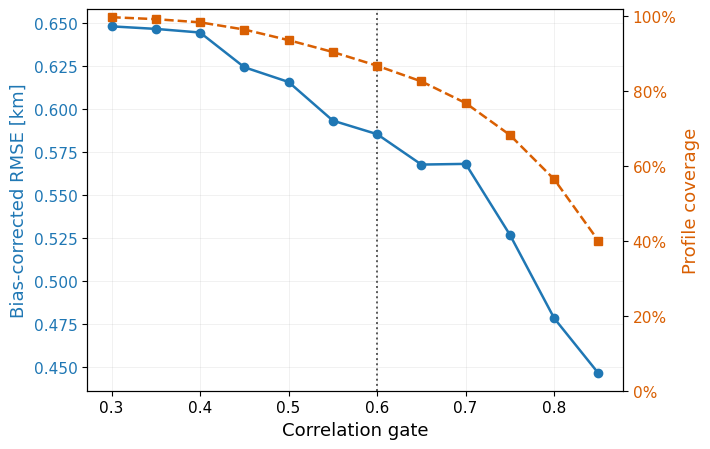

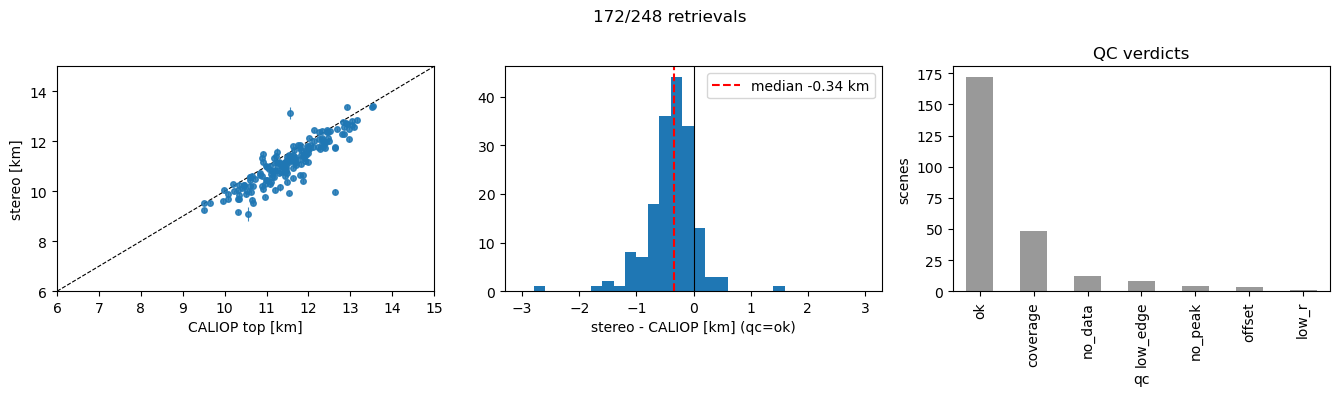

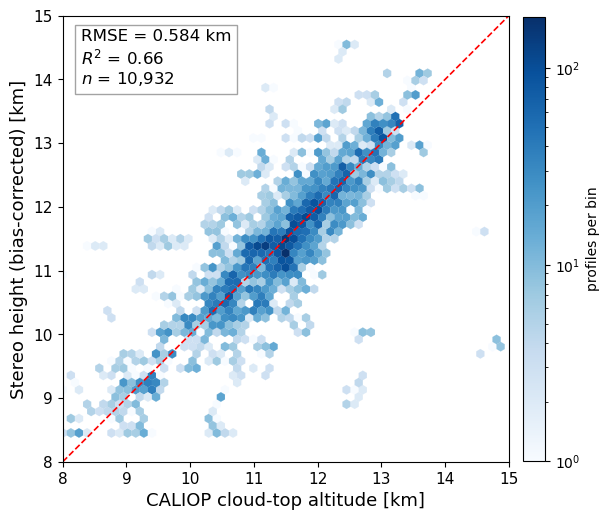

In [3]:
%matplotlib inline
from contrailstereo.vis import summary as VS, scene as VZ
from contrailstereo.validation import metrics as M
from contrailstereo.core.retrieve import run_scene

VS.run_summary("/Users/lewisclark/Documents/python_work/stereo/outputs/results_1315.csv")
VS.map_scatter("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv", gate=0.6)
VS.tradeoff_plot("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv", save="/Users/lewisclark/Documents/python_work/stereo/outputs/fyr_tradeoff.pdf")

/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/vis/scene.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


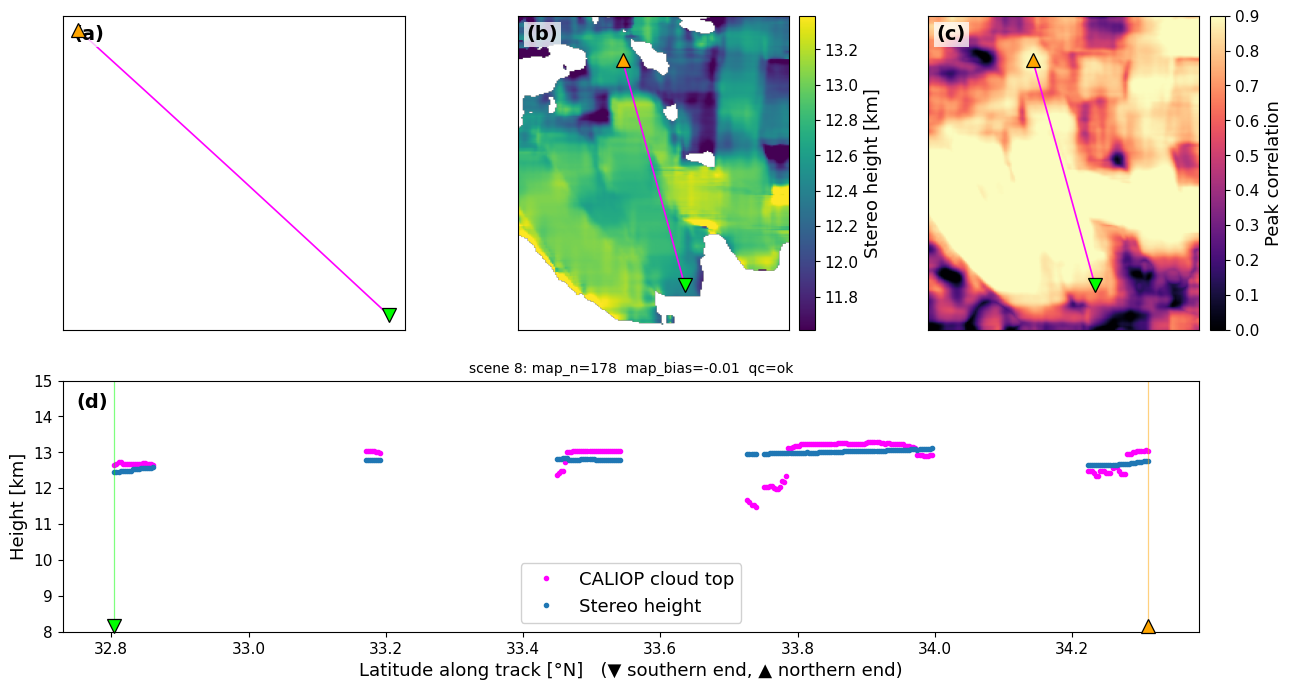

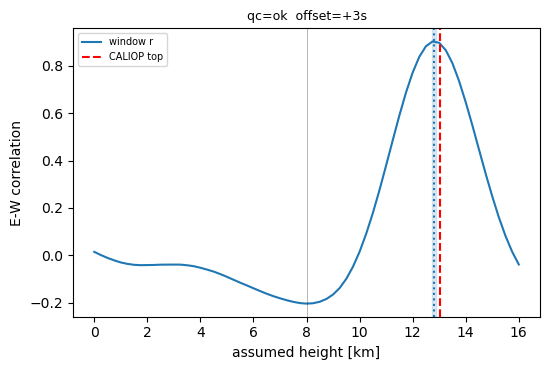

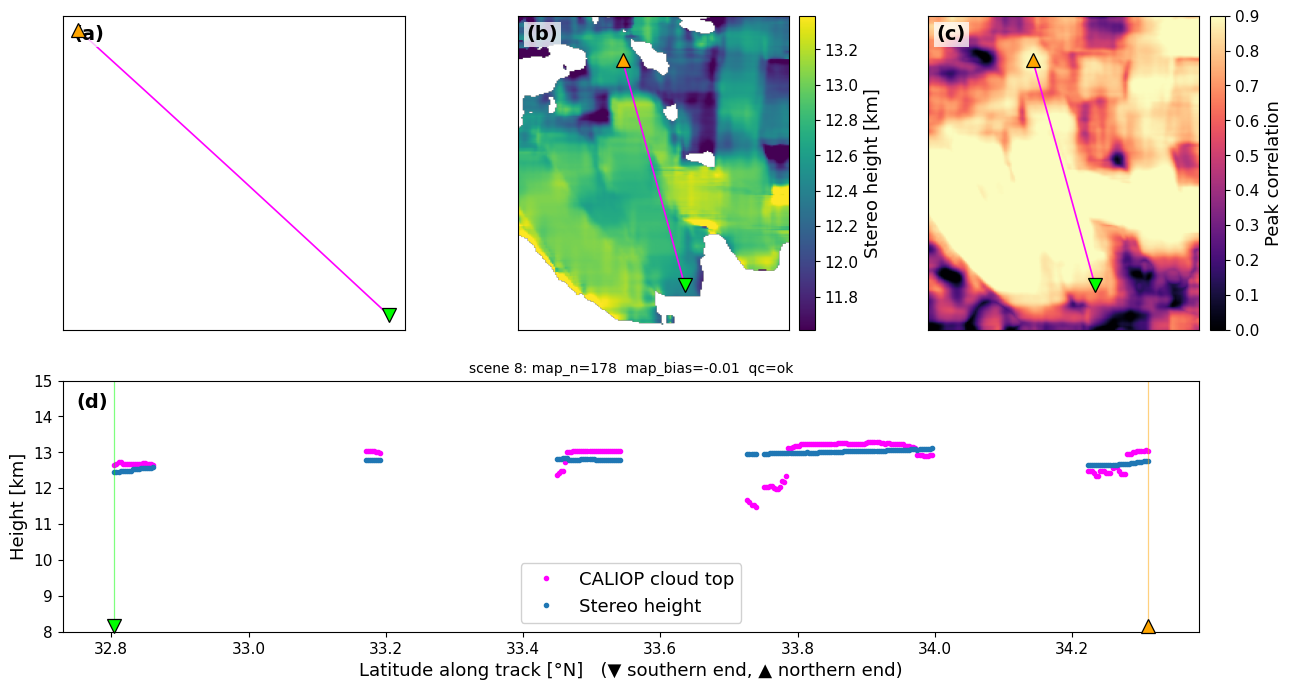

In [7]:
# per-scene, from a fixture (offline, instant):
import sys; sys.path.insert(0, "/Users/lewisclark/Documents/python_work/stereo/tests")     
from conftest import load_fixture_scene
rec, pr, extras = run_scene(load_fixture_scene(8))
VZ.curve_plot(extras, rec, truth_km=pr.top_km.median())
VZ.map_panel(extras, pr, rec, 8)

In [8]:
M.bias_correct_cv_ci("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv")

(0.48641762198886146, 0.7053712932864153)

In [9]:
pp = pd.read_csv("/Users/lewisclark/Documents/python_work/stereo/outputs/profiles1315.csv").dropna(subset=["h_map"])
q = pp[pp.r_map > 0.6].assign(e=lambda d: d.h_map - d.top_km)
sc = (q.assign(e2=q.e**2).groupby("scene")
        .agg(n=("e","size"), bias=("e","mean"), sse=("e2","sum")))
sc["share"] = sc.sse / sc.sse.sum()
print(sc.sort_values("share", ascending=False).head(8).round(3))
print(f"\ntop-5 scenes carry {sc.share.nlargest(5).sum():.0%} of squared error")

         n   bias      sse  share
scene                            
103     35 -3.872  623.616  0.132
137     55 -1.433  413.627  0.088
49      97 -1.162  218.979  0.046
60      37 -0.784  150.428  0.032
62      44 -1.724  136.246  0.029
27     123 -0.214  109.614  0.023
0      298 -0.203  109.141  0.023
187     32 -1.719   94.809  0.020

top-5 scenes carry 33% of squared error
